# ANOVA

## Overview

ANOVA tests whether three or more group means are equal by partitioning variance into between-group and within-group components. It is an omnibus test — a significant result only indicates at least one pair differs. Post-hoc tests identify which pairs.

| Method | When to use |
|---|---|
| One-way ANOVA | Equal variances, one factor |
| Welch ANOVA | Unequal variances |
| Two-way ANOVA | Two factors, test for interaction |
| Tukey HSD post-hoc | Equal group sizes, controls FWER |
| Games-Howell post-hoc | Unequal variances or sizes |

---

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.formula.api import ols
import statsmodels.api as sm

rng = np.random.default_rng(42)
catchments = ["North","South","East","West"]
means = {"North":18.0,"South":21.0,"East":19.5,"West":16.5}
df = pd.DataFrame({
    "catchment": np.repeat(catchments, 40),
    "richness":  np.concatenate([rng.normal(means[c], 5, 40) for c in catchments]),
    "treatment": np.tile(["control","restored"], 80)
})
print(df.groupby("catchment")["richness"].agg(["mean","std","count"]).round(2))

            mean   std  count
catchment                    
East       18.34  3.94     40
North      18.19  4.13     40
South      21.07  3.65     40
West       16.18  5.40     40


---
## One-Way ANOVA

In [2]:
groups = [df.loc[df["catchment"]==c,"richness"].values for c in catchments]
F, p = stats.f_oneway(*groups)
print(f"One-way ANOVA: F={F:.3f}, p={p:.4f}")
# Effect size: omega-squared (bias-corrected)
ss_b = sum(len(g)*(g.mean()-df["richness"].mean())**2 for g in groups)
ss_w = sum(sum((g - g.mean())**2) for g in groups)
df_b = len(groups) - 1
ms_w = ss_w / (len(df) - len(groups))
omega2 = (ss_b - df_b*ms_w) / (ss_b + ss_w + ms_w)
print(f"omega-squared = {omega2:.3f}  (small=0.01, medium=0.06, large=0.14)")

One-way ANOVA: F=8.583, p=0.0000
omega-squared = 0.124  (small=0.01, medium=0.06, large=0.14)


---
## Post-Hoc: Tukey HSD

Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
  East  North  -0.1454 0.9988   -2.66  2.3691  False
  East  South   2.7291 0.0276  0.2145  5.2437   True
  East   West  -2.1558 0.1206 -4.6704  0.3588  False
 North  South   2.8746  0.018    0.36  5.3891   True
 North   West  -2.0104 0.1655  -4.525  0.5042  False
 South   West   -4.885    0.0 -7.3995 -2.3704   True
----------------------------------------------------


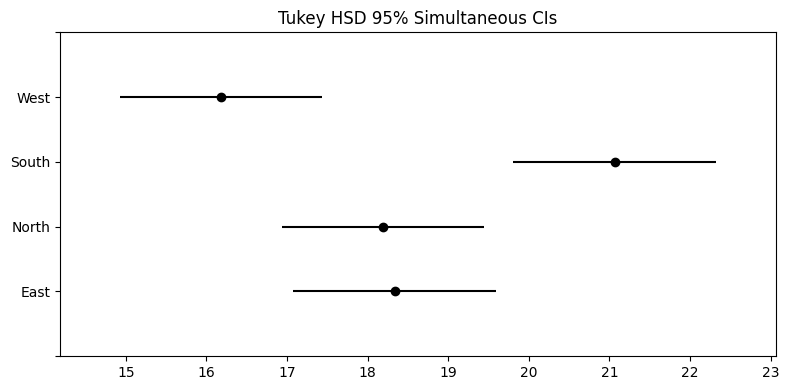

In [3]:
tukey = pairwise_tukeyhsd(df["richness"], df["catchment"], alpha=0.05)
print(tukey)
tukey.plot_simultaneous(figsize=(8,4))
plt.title("Tukey HSD 95% Simultaneous CIs")
plt.tight_layout(); plt.show()

---
## Two-Way ANOVA with Interaction

In [4]:
# Type III SS -- correct for unbalanced designs
model = ols("richness ~ C(catchment) + C(treatment) + C(catchment):C(treatment)", data=df).fit()
aov = sm.stats.anova_lm(model, typ=3)
print(aov.round(4))
print("\nCheck interaction first -- if significant, main effects not interpretable alone")

                              sum_sq     df         F  PR(>F)
Intercept                  6939.7037    1.0  370.1782  0.0000
C(catchment)                202.6603    3.0    3.6034  0.0149
C(treatment)                  3.3821    1.0    0.1804  0.6716
C(catchment):C(treatment)    75.5221    3.0    1.3428  0.2626
Residual                   2849.5327  152.0       NaN     NaN

Check interaction first -- if significant, main effects not interpretable alone


---
## Residual Diagnostics

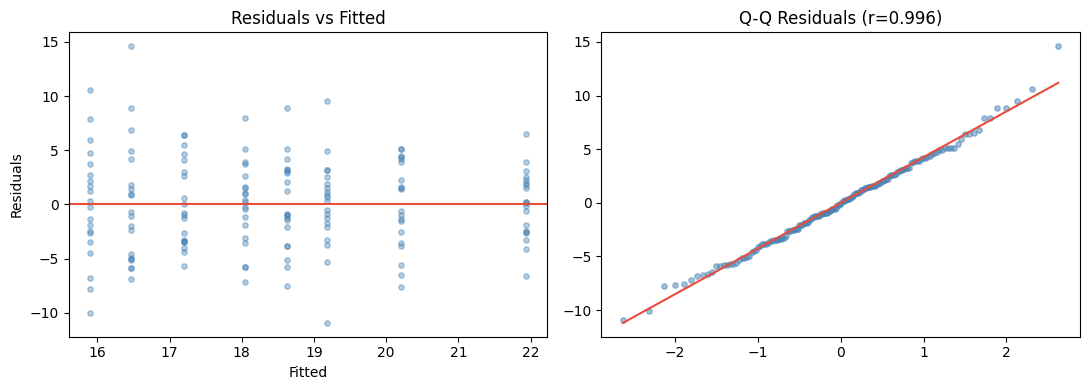

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))
resid = model.resid; fitted = model.fittedvalues
axes[0].scatter(fitted, resid, alpha=0.4, s=15, color="steelblue")
axes[0].axhline(0, color="#e74c3c", lw=1.5)
axes[0].set_xlabel("Fitted"); axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")
(osm,osr),(sl,ic,r) = stats.probplot(resid, dist="norm")
axes[1].scatter(osm, osr, s=15, alpha=0.5, color="steelblue")
axes[1].plot(osm, sl*np.array(osm)+ic, color="#e74c3c", lw=1.5)
axes[1].set_title(f"Q-Q Residuals (r={r:.3f})")
plt.tight_layout(); plt.show()

---

## Common Pitfalls

**1. Not following omnibus F with post-hoc tests**  
ANOVA only tells you at least one pair differs. Tukey HSD or Games-Howell identify which pairs.

**2. Interpreting main effects when the interaction is significant**  
A significant interaction means the effect of one factor depends on the level of the other. Main effects are averages across levels and are misleading when the interaction matters.

**3. Not using Welch ANOVA for unequal variances**  
Standard ANOVA assumes homogeneity of variance. When Levene rejects, use `pingouin.welch_anova` and Games-Howell post-hoc.

**4. Using Type I SS for unbalanced designs**  
`anova_lm` defaults to Type I (sequential) SS, which is order-dependent. Always use `typ=3` for unbalanced designs.

**5. Not checking residual diagnostics**  
ANOVA assumes normally distributed residuals and homoscedasticity. Always plot residuals vs fitted and a Q-Q plot before interpreting results.
---
*python_methods_library - Samantha McGarrigle*